<a href="https://www.kaggle.com/code/jeisamathew/churn-analysis?scriptVersionId=341025402" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Step 1: -  Import Libraries needed for the whole project and Load Dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv


In [2]:
#import other neccessary libaries for Visualisation:

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use("ggplot")

In [3]:
# Load the dataset
df = pd.read_csv("/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv")

In [4]:
# **Display the first few rows:**
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Step 2: -  Understand the Dataset

In [5]:
df.shape

(10000, 14)

In [6]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [7]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# Step 3: -  Data Cleaning

In [9]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

**No missing values were found, indicating that the dataset is complete and ready for analysis.**

In [10]:
df.duplicated().sum()

np.int64(0)

**No duplicate records were found.**

In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**The statistical summary provides an overview of customer demographics, balances, salaries, and account characteristics.**

# Step 4: - Univariate Analysis

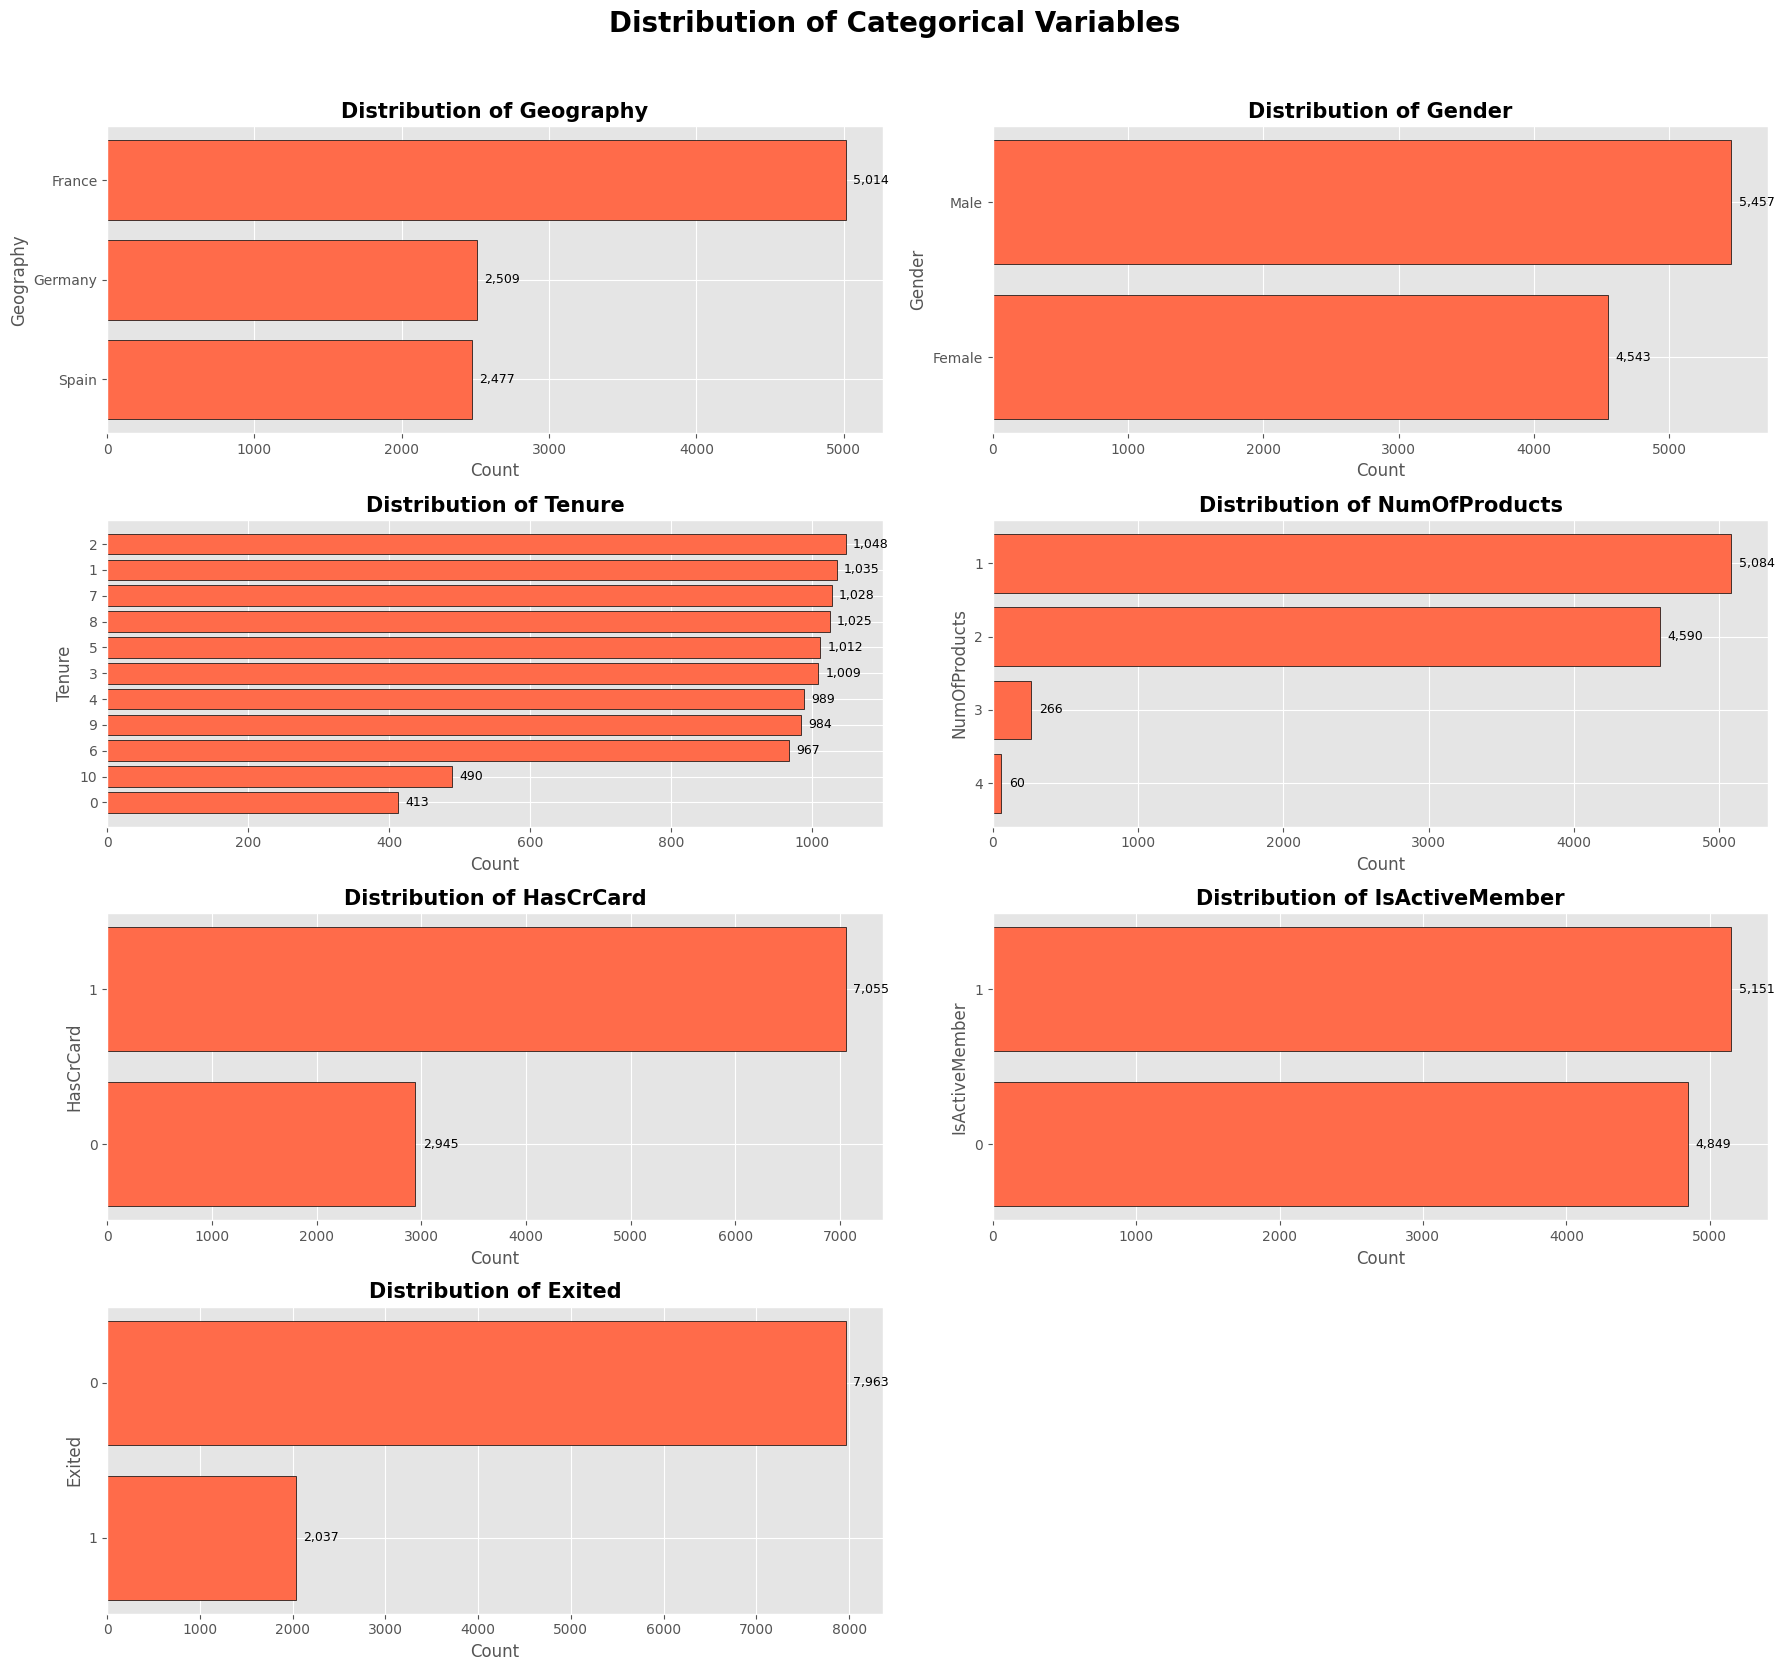

In [12]:
# Categorical Columns in Horizontal Bar Charts:
cat_cols = [
    'Geography',
    'Gender',
    'Tenure',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember',
    'Exited'
]

fig, axes = plt.subplots(
    4, 2,
    figsize=(18, 17)
)

axes = axes.ravel()

for i, col in enumerate(cat_cols):

    counts = df[col].value_counts().sort_values()

    axes[i].barh(
        counts.index.astype(str),
        counts.values,
        color='#FF6B4A',
        edgecolor='black'
    )

    axes[i].set_title(
        f'Distribution of {col}',
        fontsize=15,
        fontweight='bold'
    )

    axes[i].set_xlabel('Count', fontsize=12)
    axes[i].set_ylabel(col, fontsize=12)

    # Add value labels
    for j, val in enumerate(counts.values):
        axes[i].text(
            val + (counts.max() * 0.01),
            j,
            f'{val:,}',
            va='center',
            fontsize=9
        )

# Remove the unused subplot
axes[-1].remove()

fig.suptitle(
    'Distribution of Categorical Variables',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

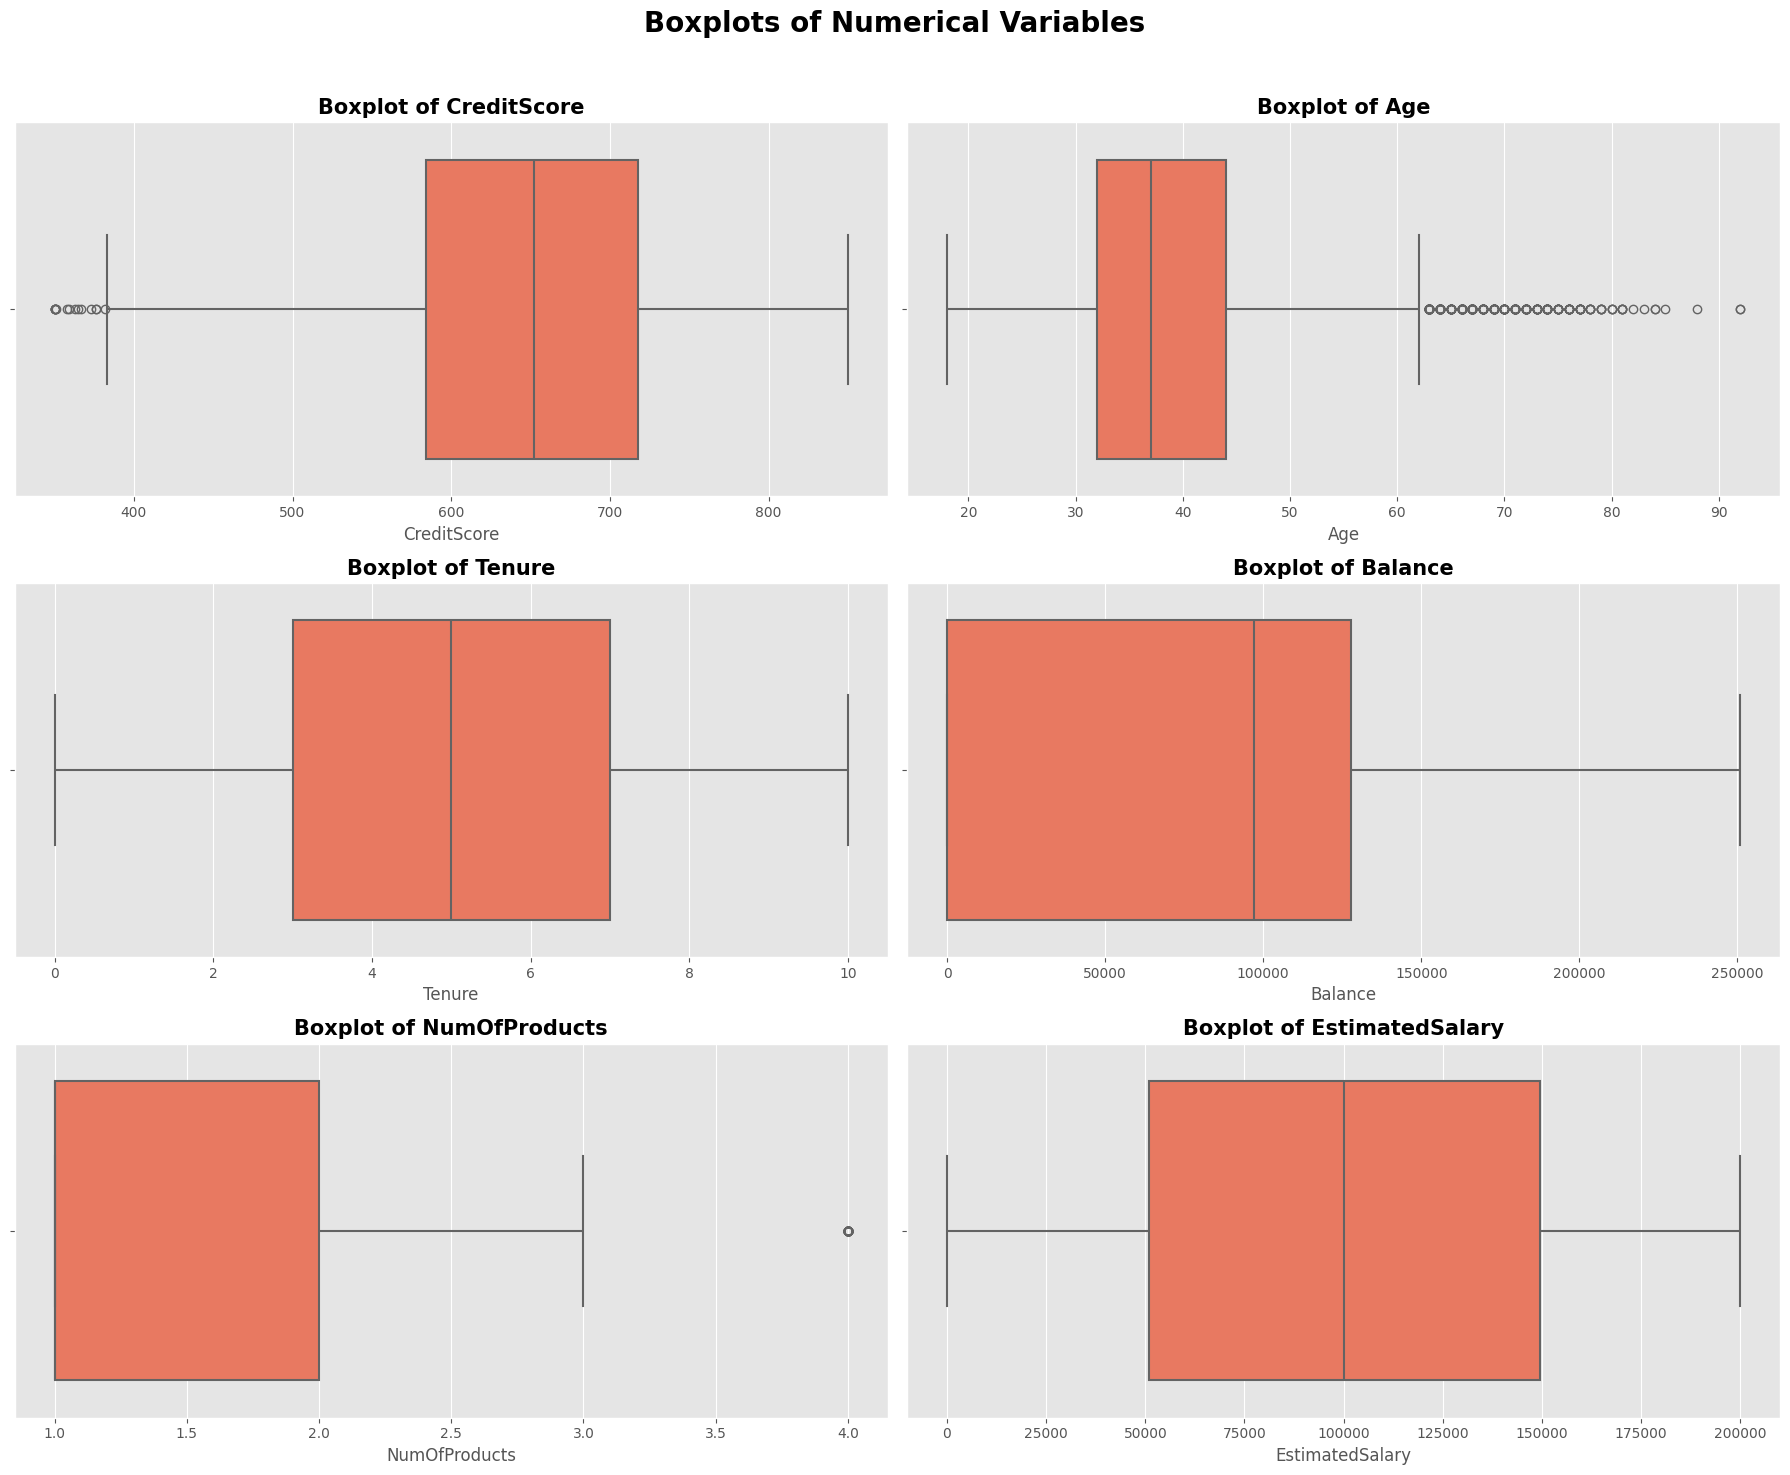

In [13]:
#Numerical Columns Distribution in Boxplots:
num_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.ravel()

for i, col in enumerate(num_cols):

    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color='#FF6B4A',
        linewidth=1.5
    )

    axes[i].set_title(
        f'Boxplot of {col}',
        fontsize=15,
        fontweight='bold'
    )

    axes[i].set_xlabel(
        col,
        fontsize=12
    )

    axes[i].set_ylabel('')

fig.suptitle(
    'Boxplots of Numerical Variables',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Step 5:- Bivariate Analysis

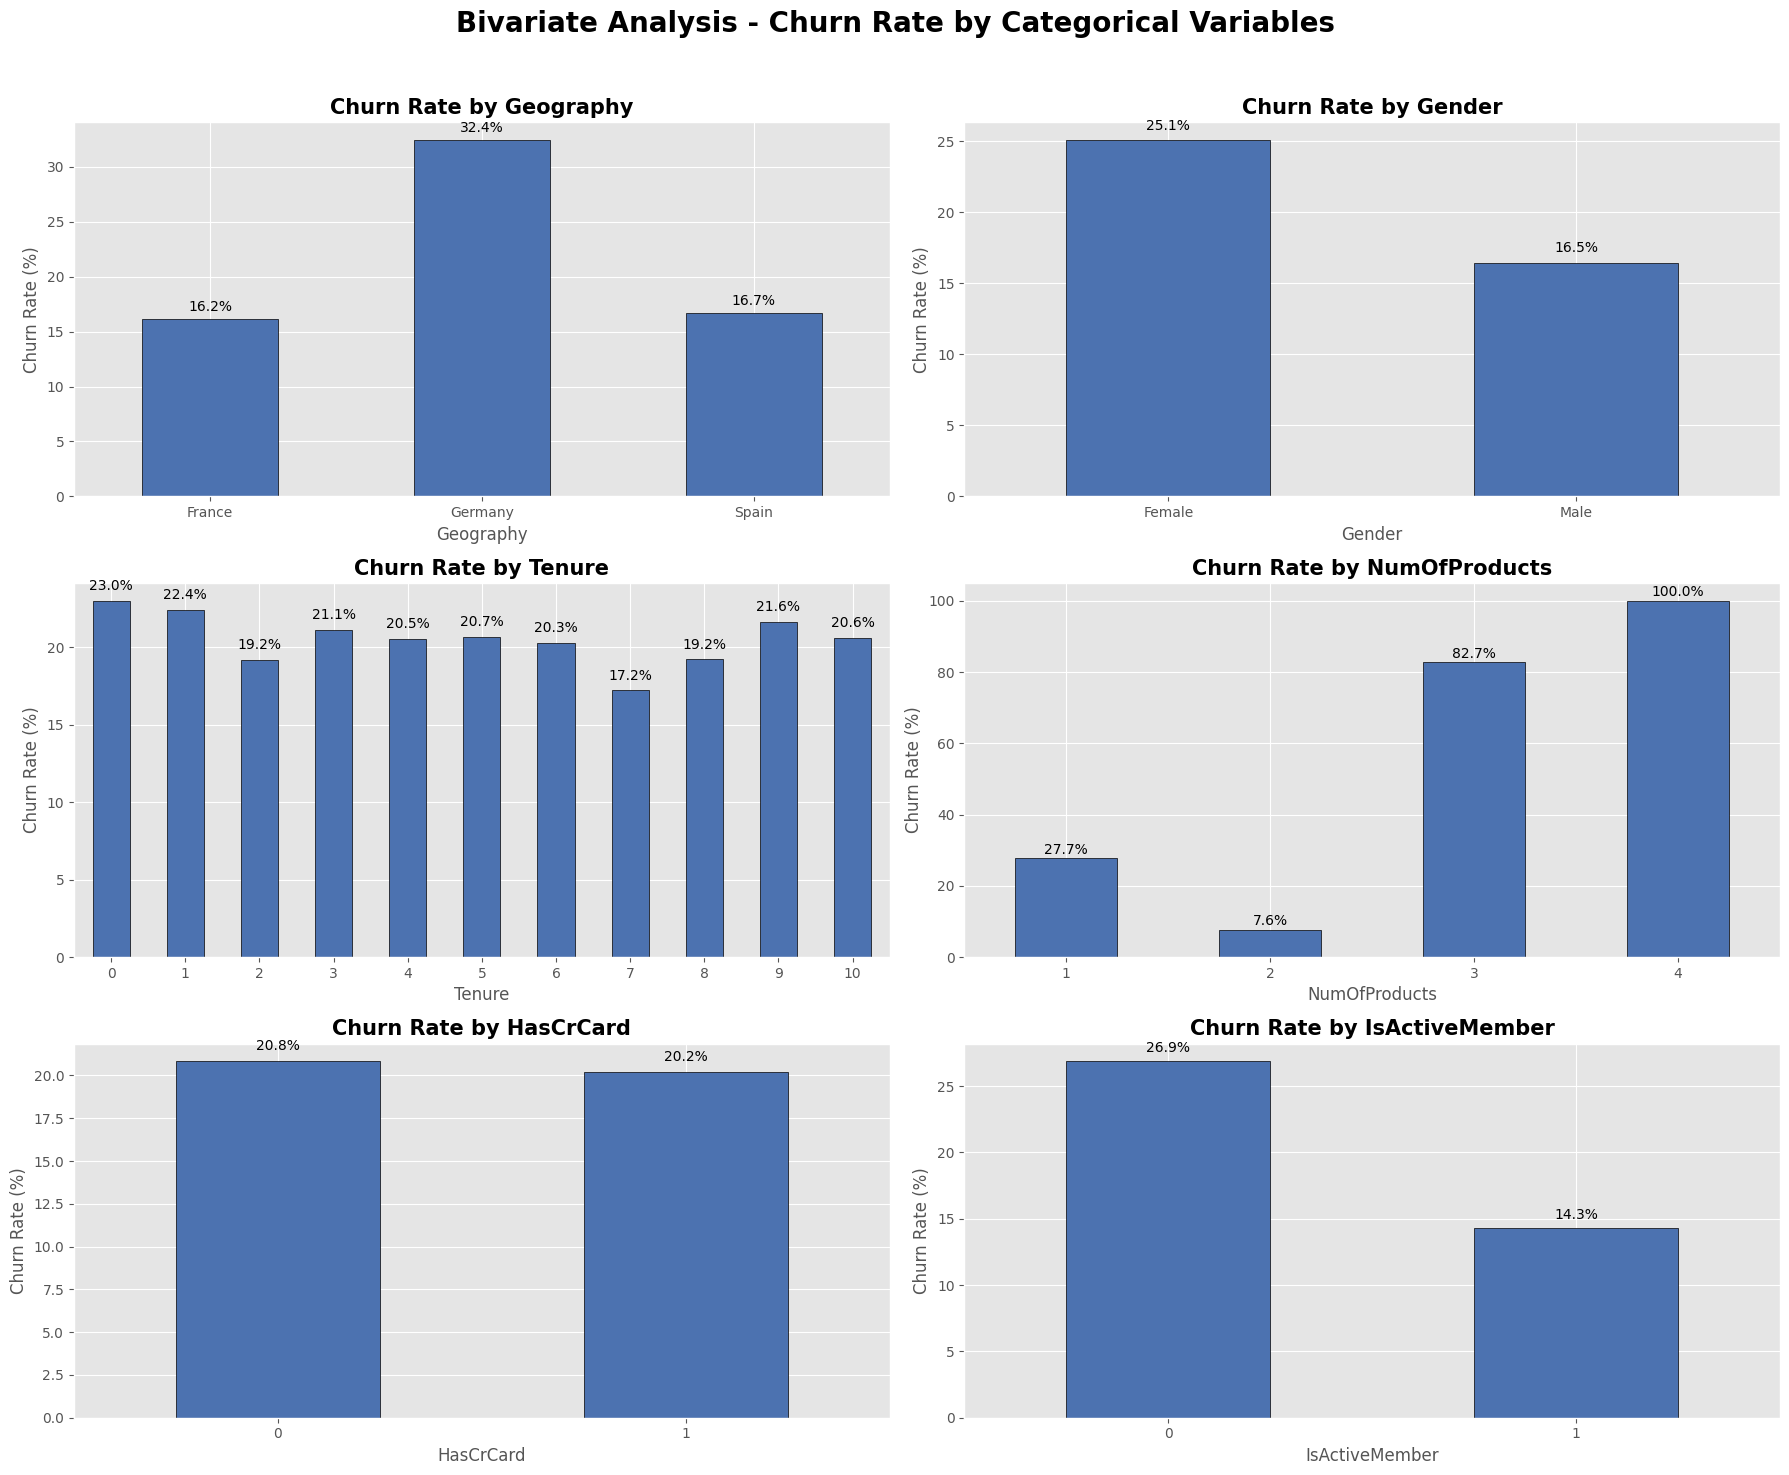

In [14]:
#Vertical Column Bar Charts:
bivariate_cols = [
    'Geography',
    'Gender',
    'Tenure',
    'NumOfProducts',
    'HasCrCard',
    'IsActiveMember'
]

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.ravel()

for i, col in enumerate(bivariate_cols):

    # Calculate churn rate
    churn_rate = (
        df.groupby(col)['Exited']
        .mean()
        .mul(100)
    )

    # Create vertical bar chart
    churn_rate.plot(
        kind='bar',
        ax=axes[i],
        color='#4C72B0',
        edgecolor='black'
    )

    axes[i].set_title(
        f'Churn Rate by {col}',
        fontsize=15,
        fontweight='bold'
    )

    axes[i].set_xlabel(
        col,
        fontsize=12
    )

    axes[i].set_ylabel(
        'Churn Rate (%)',
        fontsize=12
    )

    axes[i].tick_params(
        axis='x',
        rotation=0
    )

    # Add percentage labels
    for j, val in enumerate(churn_rate):
        axes[i].text(
            j,
            val + 0.5,
            f'{val:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10
        )

fig.suptitle(
    'Bivariate Analysis - Churn Rate by Categorical Variables',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

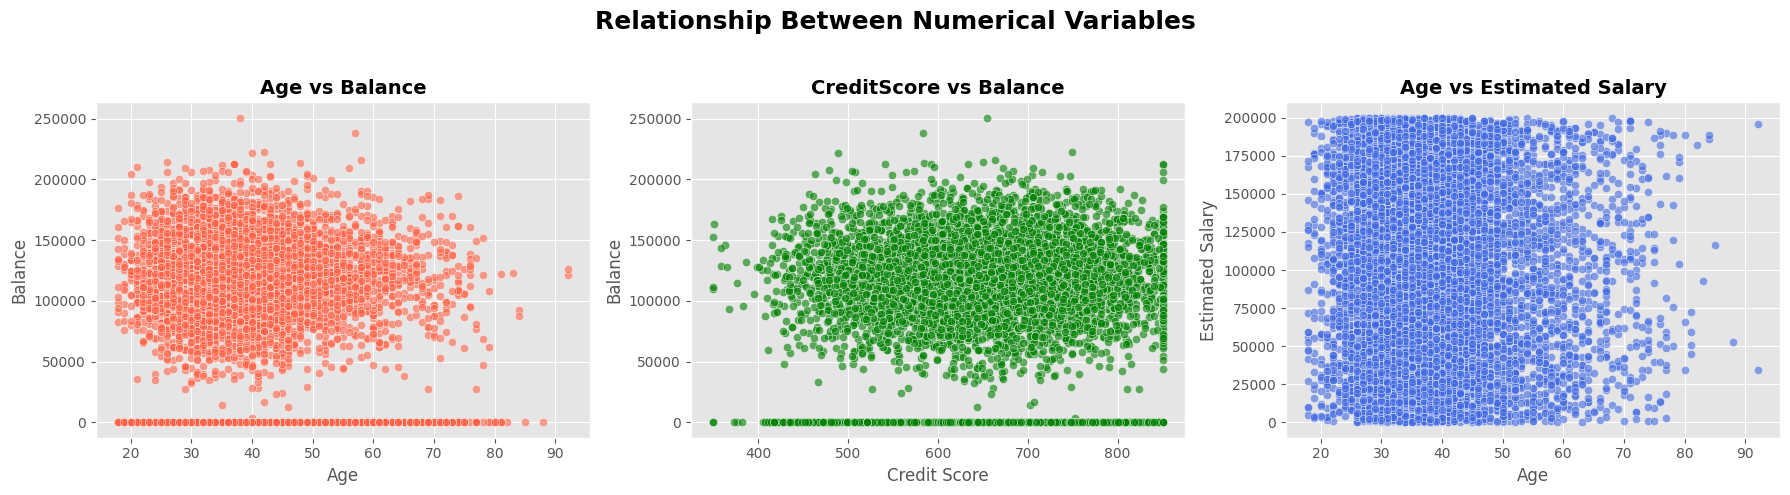

In [15]:
# Scatter Plot Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age vs Balance

sns.scatterplot(
    data=df,
    x='Age',
    y='Balance',
    ax=axes[0],
    color='tomato',
    alpha=0.6
)

axes[0].set_title(
    'Age vs Balance',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Age')
axes[0].set_ylabel('Balance')


# CreditScore vs Balance

sns.scatterplot(
    data=df,
    x='CreditScore',
    y='Balance',
    ax=axes[1],
    color='green',
    alpha=0.6
)

axes[1].set_title(
    'CreditScore vs Balance',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Balance')


# Age vs EstimatedSalary

sns.scatterplot(
    data=df,
    x='Age',
    y='EstimatedSalary',
    ax=axes[2],
    color='royalblue',
    alpha=0.6
)

axes[2].set_title(
    'Age vs Estimated Salary',
    fontsize=14,
    fontweight='bold'
)

axes[2].set_xlabel('Age')
axes[2].set_ylabel('Estimated Salary')


# Main title

fig.suptitle(
    'Relationship Between Numerical Variables',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Step 5: - Correlation Matrix

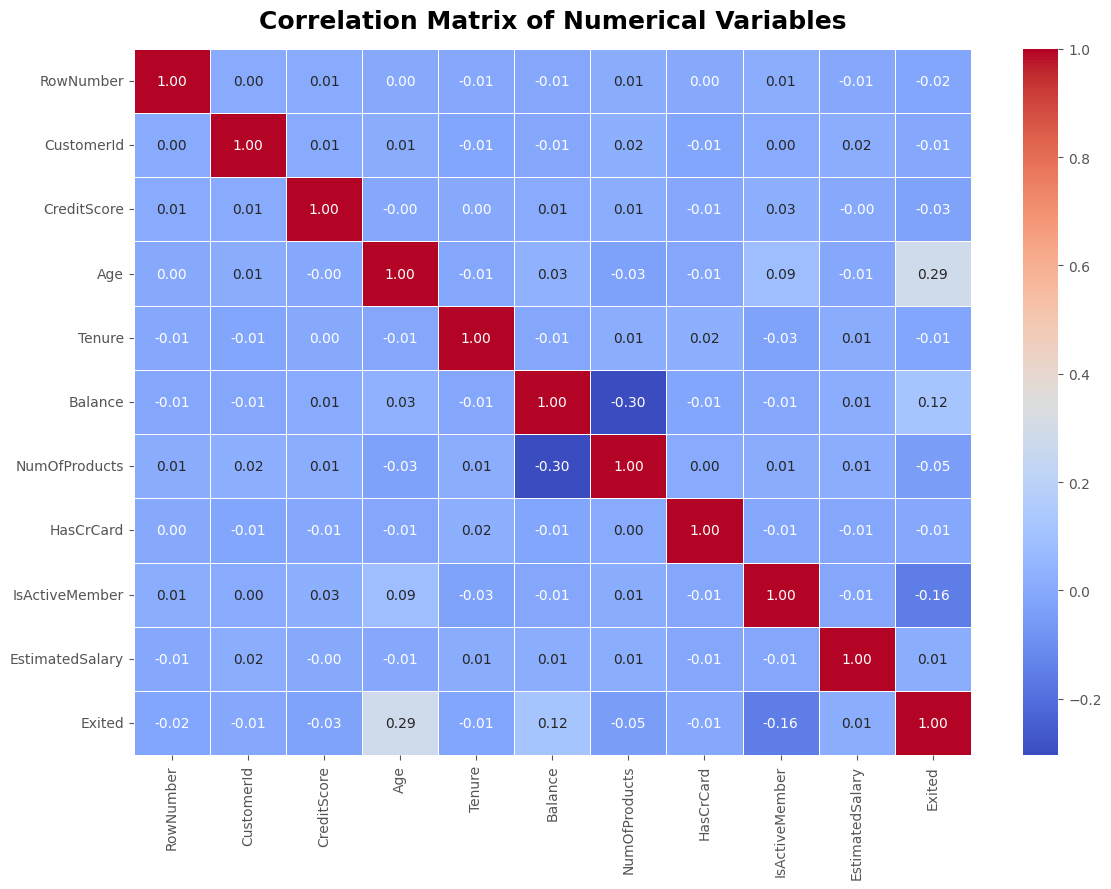

In [16]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Matrix of Numerical Variables',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.tight_layout()
plt.show()

# Step 6: - Save Cleaned Data

In [17]:
# 1. Load the raw dataset
raw_path = "/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv"
df = pd.read_csv(raw_path)

# 2. Define 'df_clean' by processing your data
# This step creates the missing variable name
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')

# 3. Save the defined variable to your working directory
df_clean.to_csv("/kaggle/working/Churn_Modelling_Cleaned.csv", index=False)

print("File successfully saved to your Kaggle working output directory!")

File successfully saved to your Kaggle working output directory!


In [18]:
from IPython.display import FileLink
FileLink('Churn_Modelling_Cleaned.csv')

/kaggle/working/Churn_Modelling_Cleaned.csv